In [1]:
from pathlib import Path


from modules.peak_fitter import PeakFitter, FitConfig


print("All done.")

All done.


In [2]:
# Define data location
folder = "data/PyrIR_OMAS_1-5_T80/corr"
cwd = Path.cwd()
path_to_directory = cwd / folder
print(path_to_directory)

# Optional: configure fitting parameters
config = FitConfig(
    threshold=0.01
)

# Initialize the handler
handler = PeakFitter(path_to_directory=path_to_directory, folder=folder, fit_config=config)
handler.available_files()


c:\Users\Selina Itzigehl\Documents\GitHub\FAIRVibSpec\data\PyrIR_OMAS_1-5_T80\corr


{0: 'PyrIR_OMAS_1-5_T80_360min-450C_30min-4mbar-Pyr-RT_30min-300C-Pyr-des_corr',
 1: 'PyrIR_OMAS_1-5_T80_360min-450C_30min-4mbar-Pyr-RT_30min-350C-Pyr-des_corr',
 2: 'PyrIR_OMAS_1-5_T80_360min-450C_30min-4mbar-Pyr-RT_30min-400C-Pyr-des_corr',
 3: 'PyrIR_OMAS_1-5_T80_360min-450C_30min-4mbar-Pyr-RT_30min-450C-Pyr-des_corr',
 4: 'PyrIR_OMAS_1-5_T80_360min-450C_30min-4mbar-Pyr-RT_60min-150C-Pyr-des_corr',
 5: 'PyrIR_OMAS_1-5_T80_360min-450C_30min-4mbar-Pyr-RT_60min-200C-Pyr-des_corr',
 6: 'PyrIR_OMAS_1-5_T80_360min-450C_30min-4mbar-Pyr-RT_60min-250C-Pyr-des_corr'}

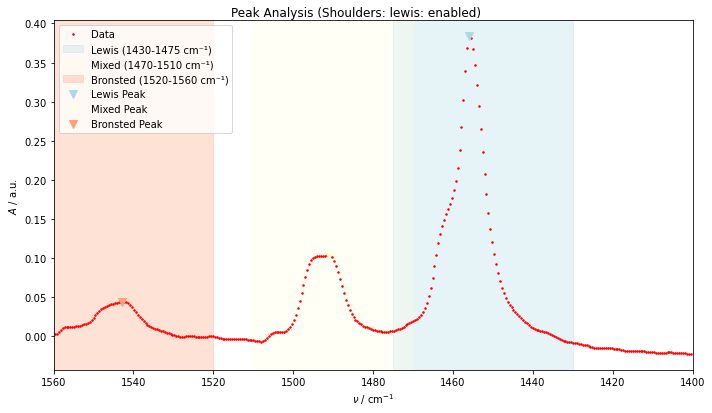

In [7]:
index = 2
handler.extract_data(index=index)
handler.get_control_plot(index = index)

Shoulder fitting for lewis region enabled
Starting analysis...
Available regions: ['lewis', 'mixed', 'bronsted']

Analyzing lewis region...
Wavenumber range: 1430 - 1475 cm⁻¹
Found 93 data points in range
Attempt 1: Using shoulder fit for lewis region
Fit successful with acceptable residuals after 1 attempts
Fit successful - Area: 4.5453, Shoulder: True, Error: 0.0092

Analyzing mixed region...
Wavenumber range: 1470 - 1510 cm⁻¹
Found 83 data points in range
Attempt 1: Using single Voigt fit for mixed region
Fit successful with acceptable residuals after 1 attempts
Fit successful - Area: 1.2761, Shoulder: False, Error: 0.0054

Analyzing bronsted region...
Wavenumber range: 1520 - 1560 cm⁻¹
Found 83 data points in range
Attempt 1: Using single Voigt fit for bronsted region
Fit successful with acceptable residuals after 1 attempts
Fit successful - Area: 0.6440, Shoulder: False, Error: 0.0019

Analysis complete.
Successfully analyzed 3 regions

Analysis Results:
--------------------------

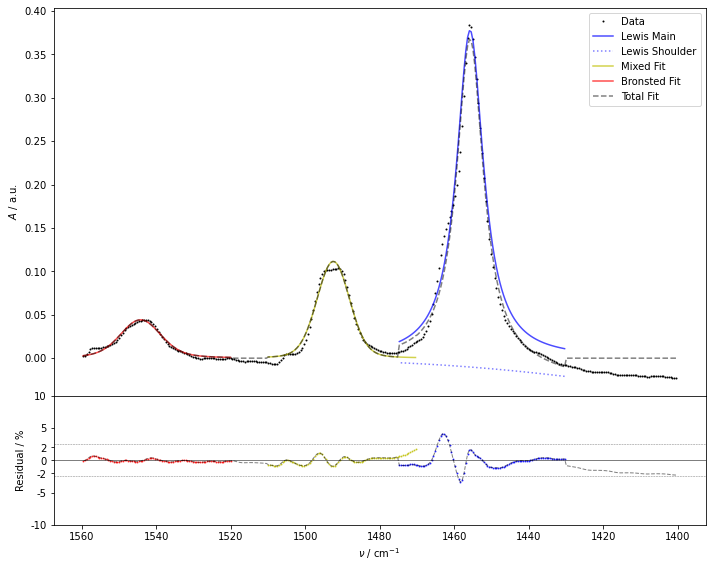

In [8]:
handler.force_shoulder("lewis", force=True)

# Run the main analysis
handler.analyze()

# View results (areas, shoulder detection)
print(handler.print_results())
handler.plot_results(index=index)

In [5]:
handler.calc_n_sites(
    sample_length=1.974,
    sample_width=1.061,
    sample_mass=0.0874,
    extinction_coefficient_bronsted=2.22,
    extinction_coefficient_lewis=1.67,
    error_sample_mass=0.001,
    error_sample_length=0.01,
    error_sample_width=0.01
)


Starting analysis...
Available regions: ['lewis', 'mixed', 'bronsted']

Analyzing lewis region...
Wavenumber range: 1430 - 1475 cm⁻¹
Found 93 data points in range
Attempt 1: Using shoulder fit for lewis region
Fit successful with acceptable residuals after 1 attempts
Fit successful - Area: 4.4842, Shoulder: True, Error: 0.0109

Analyzing mixed region...
Wavenumber range: 1470 - 1510 cm⁻¹
Found 83 data points in range
Attempt 1: Using single Voigt fit for mixed region
Fit successful with acceptable residuals after 1 attempts
Fit successful - Area: 1.0059, Shoulder: False, Error: 0.0060

Analyzing bronsted region...
Wavenumber range: 1520 - 1560 cm⁻¹
Found 83 data points in range
Attempt 1: Using single Voigt fit for bronsted region
Fit successful with acceptable residuals after 1 attempts
Fit successful - Area: 0.3540, Shoulder: False, Error: 0.0015

Analysis complete.
Successfully analyzed 3 regions


[0.0038212086984804098,
 6.192026575830718e-05,
 0.06434590665012219,
 0.0010200558310349106]

In [6]:
if handler.get_file_by_index(index).name.endswith("150C-Pyr-des_corr.csv"):
    handler.save_json("results.json")
else:
    handler.update_json("results.json", index=index)


Measurement for PyrIR_OMAS_1-5_T80_360min-450C_30min-4mbar-Pyr-RT_30min-450C-Pyr-des not found in JSON.
Data in results.json updated.
